### # 📊 Module 3: Data Processing & Exploratory Analysis


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from ydata_profiling import ProfileReport

%matplotlib inline


C:\Users\91755\web_scraping_project\scraping_env_311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### ### 📌 Load Dataset


In [3]:
df = pd.read_csv("scraped_data.csv")
df.head()


,Quote,Author
0,“The world as we have created it is a process ...,Albert Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling
2,“There are only two ways to live your life. On...,Albert Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe


In [4]:
df.info()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Quote   10 non-null     object
 1   Author  10 non-null     object
dtypes: object(2)
memory usage: 288.0+ bytes


0

In [5]:
df.drop_duplicates(inplace=True)

df.fillna({
    col: "Unknown" if df[col].dtype == "object" else df[col].mean()
    for col in df.columns
}, inplace=True)


In [6]:
df.describe(include="all")


,Quote,Author
count,10,10
unique,10,8
top,“The world as we have created it is a process ...,Albert Einstein
freq,1,3


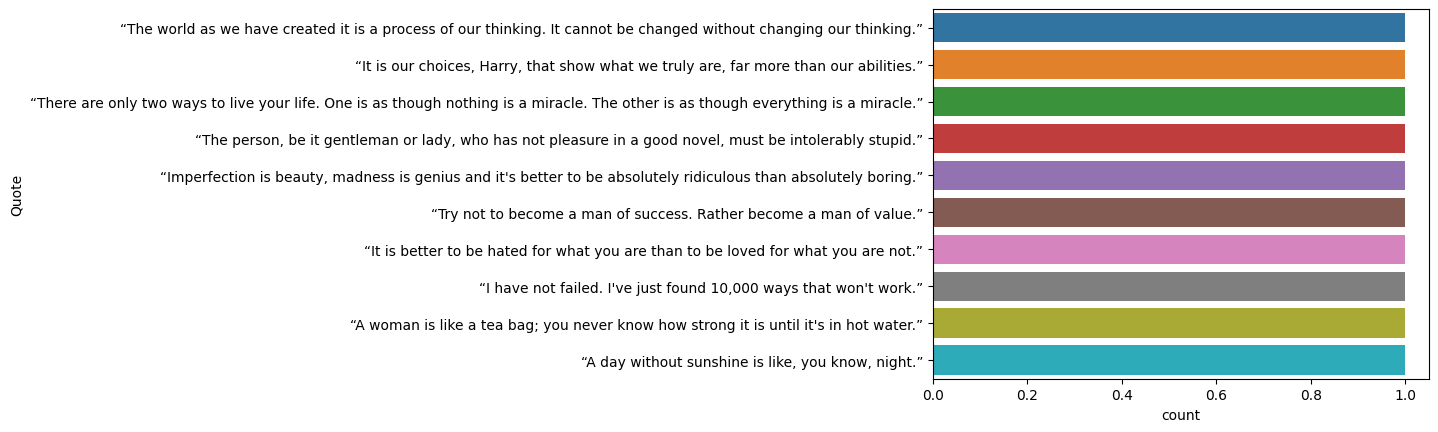

In [13]:
categorical_cols = df.select_dtypes(include=["object"]).columns
if len(categorical_cols) > 0:
    sns.countplot(y=df[categorical_cols[0]])
    plt.show()


In [15]:
text_col = None
for col in df.columns:
    if df[col].dtype == "object" and df[col].str.len().mean() > 10:
        text_col = col
        break

text_col


'Quote'

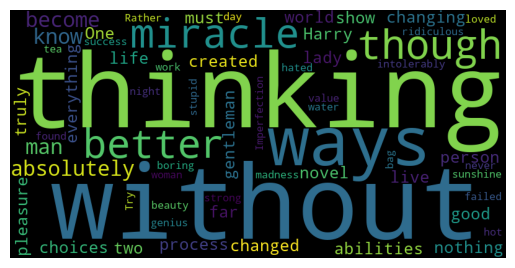

In [16]:
if text_col:
    text = " ".join(df[text_col].astype(str))
    wc = WordCloud(width=800, height=400).generate(text)
    plt.imshow(wc)
    plt.axis("off")
    plt.show()


In [17]:
profile = ProfileReport(df, title="EDA Report")
profile.to_file("EDA_Report.html")


Export report to file: 100%|████████████████████████████████████████████████████| 1/1 [00:00<00:00, 442.90it/s]


In [18]:
df.to_csv("processed_dataset.csv", index=False)
"✔️ Module 3 Completed"



'✔️ Module 3 Completed'